In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

from ultralytics import YOLO
from ultralytics.data.utils import check_det_dataset

# =========================
# Paths
# =========================

DATA_YAML = "/workspace/CarDD_YOLO_Reduced/CarDD_YOLO_Reduced/data.yaml"

RUNS_DIR = Path("/workspace/runs/cardd")
RUN_NAME = "experiment_3_reduced_training_strategy"
RUN_DIR = RUNS_DIR / RUN_NAME

# =========================
# Experiment configuration
# =========================

MODEL_NAME = "yolo11n.pt"

EPOCHS = 200
IMAGE_SIZE = 640
BATCH_SIZE = 16

DEVICE = 0
WORKERS = 4

SEED = 42
DETERMINISTIC = True
AMP = True

print("Experiment 3")
print("=" * 50)
print(f"Model:       {MODEL_NAME}")
print(f"Dataset:     {DATA_YAML}")
print(f"Epochs:      {EPOCHS}")
print(f"Image size:  {IMAGE_SIZE}")
print(f"Batch size:  {BATCH_SIZE}")
print(f"Seed:        {SEED}")
print(f"Run name:    {RUN_NAME}")

Experiment 3
Model:       yolo11n.pt
Dataset:     /workspace/CarDD_YOLO_Reduced/CarDD_YOLO_Reduced/data.yaml
Epochs:      200
Image size:  640
Batch size:  16
Seed:        42
Run name:    experiment_3_reduced_training_strategy


In [3]:
data = check_det_dataset(DATA_YAML)

print("Dataset verification")
print("=" * 50)

print("Dataset path:", data["path"])
print("Train:", data["train"])
print("Val:", data["val"])
print("Test:", data["test"])

print("\nClasses:")
for class_id, class_name in data["names"].items():
    print(f"{class_id}: {class_name}")

print("\nNumber of classes:", data["nc"])

Dataset verification
Dataset path: /workspace/CarDD_YOLO_Reduced/CarDD_YOLO_Reduced
Train: /workspace/CarDD_YOLO_Reduced/CarDD_YOLO_Reduced/images/train
Val: /workspace/CarDD_YOLO_Reduced/CarDD_YOLO_Reduced/images/val
Test: /workspace/CarDD_YOLO_Reduced/CarDD_YOLO_Reduced/images/test

Classes:
0: dent
1: scratch
2: crack
3: glass shatter
4: lamp broken
5: tire flat

Number of classes: 6


In [4]:
from pathlib import Path

DATASET_ROOT = Path("/workspace/CarDD_YOLO_Reduced/CarDD_YOLO_Reduced")

for split in ["train", "val", "test"]:
    image_dir = DATASET_ROOT / "images" / split
    label_dir = DATASET_ROOT / "labels" / split

    images = list(image_dir.glob("*"))
    labels = list(label_dir.glob("*.txt"))

    print(
        f"{split.upper():5} | "
        f"images: {len(images):4} | "
        f"labels: {len(labels):4}"
    )

TRAIN | images: 1408 | labels: 1408
VAL   | images:  810 | labels:  810
TEST  | images:  375 | labels:  374


In [5]:
model = YOLO(MODEL_NAME)

print("Model loaded successfully.")
print(model.model)

Model loaded successfully.
DetectionModel(
  (model): Sequential(
    (0): Conv(
      (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (1): Conv(
      (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (2): C3k2(
      (cv1): Conv(
        (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (cv2): Conv(
        (conv): Conv2d(48, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiL

In [7]:
results = model.train(
    data=DATA_YAML,

    # =========================
    # Training duration
    # =========================
    epochs=EPOCHS,
    imgsz=IMAGE_SIZE,
    batch=BATCH_SIZE,

    # =========================
    # Hardware
    # =========================
    device=DEVICE,
    workers=WORKERS,
    amp=AMP,

    # =========================
    # Reproducibility
    # =========================
    seed=SEED,
    deterministic=DETERMINISTIC,

    # =========================
    # Training strategy
    # =========================
    optimizer="auto",
    cos_lr=True,
    patience=25,

    # =========================
    # Augmentation
    # Same as Experiment 2
    # =========================
    degrees=5.0,
    translate=0.15,
    scale=0.60,
    fliplr=0.50,
    flipud=0.0,

    mosaic=1.0,
    mixup=0.10,
    copy_paste=0.10,

    # =========================
    # Output
    # =========================
    project=str(RUNS_DIR),
    name=RUN_NAME,
    exist_ok=True,

    verbose=True
)

New https://pypi.org/project/ultralytics/8.4.152 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.144 🚀 Python-3.12.3 torch-2.8.0+cu128 CUDA:0 (NVIDIA A40, 45488MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/workspace/CarDD_YOLO_Reduced/CarDD_YOLO_Reduced/data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=200, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0

In [9]:
BEST_MODEL = RUN_DIR / "weights" / "best.pt"
LAST_MODEL = RUN_DIR / "weights" / "last.pt"

print("Best model exists:", BEST_MODEL.exists())
print("Last model exists:", LAST_MODEL.exists())

print("\nBest model:")
print(BEST_MODEL)

print("\nLast model:")
print(LAST_MODEL)

Best model exists: True
Last model exists: True

Best model:
/workspace/runs/cardd/experiment_3_reduced_training_strategy/weights/best.pt

Last model:
/workspace/runs/cardd/experiment_3_reduced_training_strategy/weights/last.pt


In [10]:
RESULTS_CSV = RUN_DIR / "results.csv"

df = pd.read_csv(RESULTS_CSV)

df.columns = df.columns.str.strip()

print("Results shape:", df.shape)

print("\nColumns:")
for col in df.columns:
    print(col)

Results shape: (193, 15)

Columns:
epoch
time
train/box_loss
train/cls_loss
train/dfl_loss
metrics/precision(B)
metrics/recall(B)
metrics/mAP50(B)
metrics/mAP50-95(B)
val/box_loss
val/cls_loss
val/dfl_loss
lr/pg0
lr/pg1
lr/pg2


In [11]:
metric_col = "metrics/mAP50-95(B)"

best_idx = df[metric_col].idxmax()
best_row = df.loc[best_idx]

best_epoch = int(best_row["epoch"]) + 1

print("Best epoch:", best_epoch)
print("Best Precision:", round(best_row["metrics/precision(B)"], 4))
print("Best Recall:", round(best_row["metrics/recall(B)"], 4))
print("Best mAP50:", round(best_row["metrics/mAP50(B)"], 4))
print("Best mAP50-95:", round(best_row["metrics/mAP50-95(B)"], 4))

Best epoch: 169
Best Precision: 0.7451
Best Recall: 0.6104
Best mAP50: 0.6582
Best mAP50-95: 0.5035


In [12]:
last_row = df.iloc[-1]

print("Final Epoch Metrics")
print("=" * 50)

print("Epoch:", int(last_row["epoch"]) + 1)
print("Precision:", round(last_row["metrics/precision(B)"], 4))
print("Recall:", round(last_row["metrics/recall(B)"], 4))
print("mAP50:", round(last_row["metrics/mAP50(B)"], 4))
print("mAP50-95:", round(last_row["metrics/mAP50-95(B)"], 4))

Final Epoch Metrics
Epoch: 194
Precision: 0.6701
Recall: 0.6286
mAP50: 0.628
mAP50-95: 0.4768


In [13]:
summary = pd.DataFrame({
    "experiment": ["Experiment 3"],
    "model": ["YOLO11n"],
    "dataset": ["CarDD Reduced"],
    "epochs": [EPOCHS],
    "best_epoch": [best_epoch],
    "imgsz": [IMAGE_SIZE],
    "batch": [BATCH_SIZE],
    "optimizer": ["auto"],
    "cos_lr": [True],
    "augmentation": ["Exp2 augmentation"],
    "precision": [best_row["metrics/precision(B)"]],
    "recall": [best_row["metrics/recall(B)"]],
    "mAP50": [best_row["metrics/mAP50(B)"]],
    "mAP50-95": [best_row["metrics/mAP50-95(B)"]]
})

summary

,experiment,model,dataset,epochs,best_epoch,imgsz,batch,optimizer,cos_lr,augmentation,precision,recall,mAP50,mAP50-95
0,Experiment 3,YOLO11n,CarDD Reduced,200,169,640,16,auto,True,Exp2 augmentation,0.74509,0.61042,0.65817,0.50352


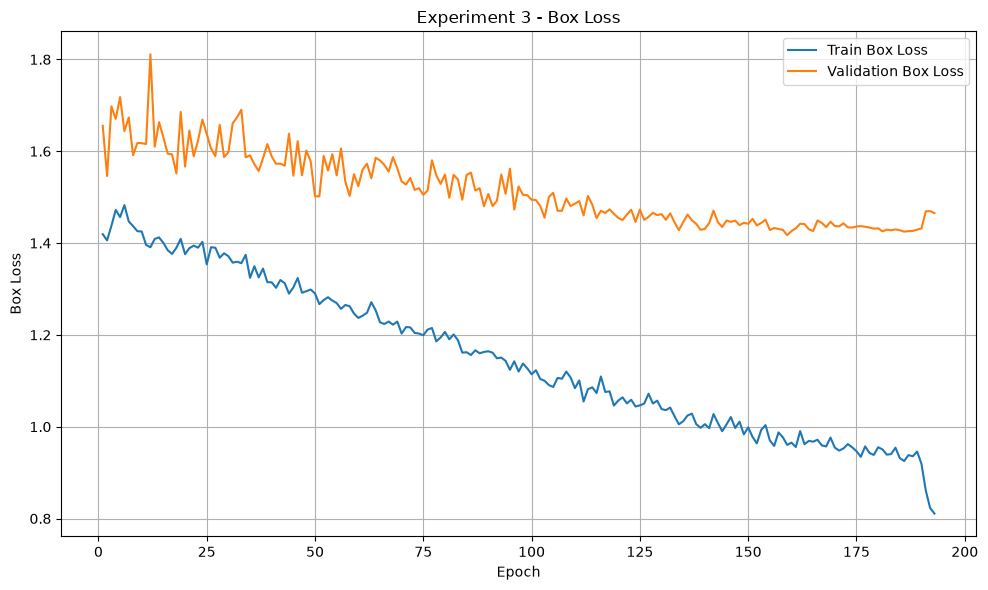

In [14]:
plt.figure(figsize=(10, 6))

plt.plot(
    df["epoch"],
    df["train/box_loss"],
    label="Train Box Loss"
)

plt.plot(
    df["epoch"],
    df["val/box_loss"],
    label="Validation Box Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Box Loss")
plt.title("Experiment 3 - Box Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    RUN_DIR / "exp3_box_loss.png",
    dpi=200
)

plt.show()

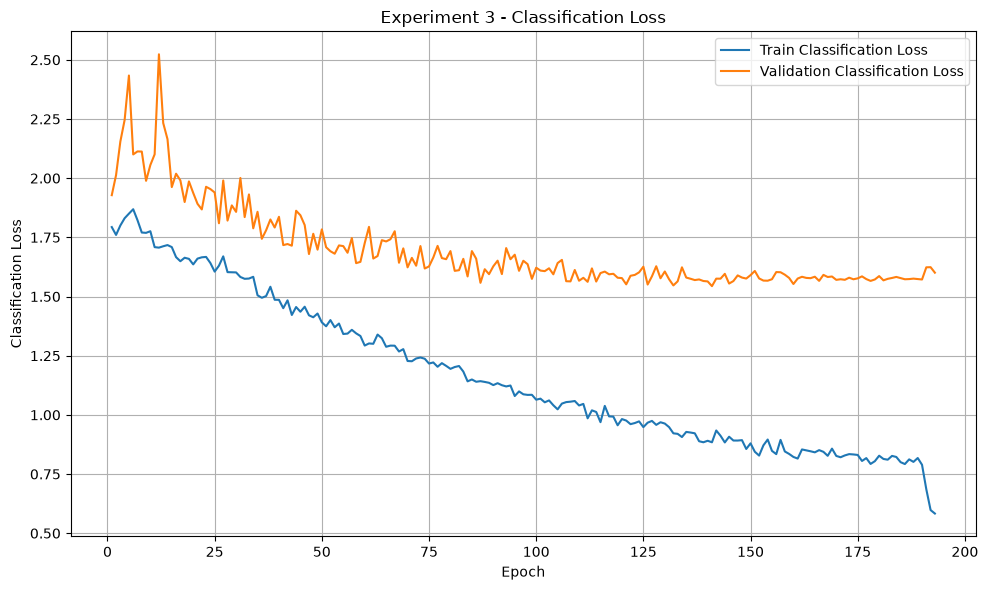

In [15]:
plt.figure(figsize=(10, 6))

plt.plot(
    df["epoch"],
    df["train/cls_loss"],
    label="Train Classification Loss"
)

plt.plot(
    df["epoch"],
    df["val/cls_loss"],
    label="Validation Classification Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Classification Loss")
plt.title("Experiment 3 - Classification Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    RUN_DIR / "exp3_classification_loss.png",
    dpi=200
)

plt.show()

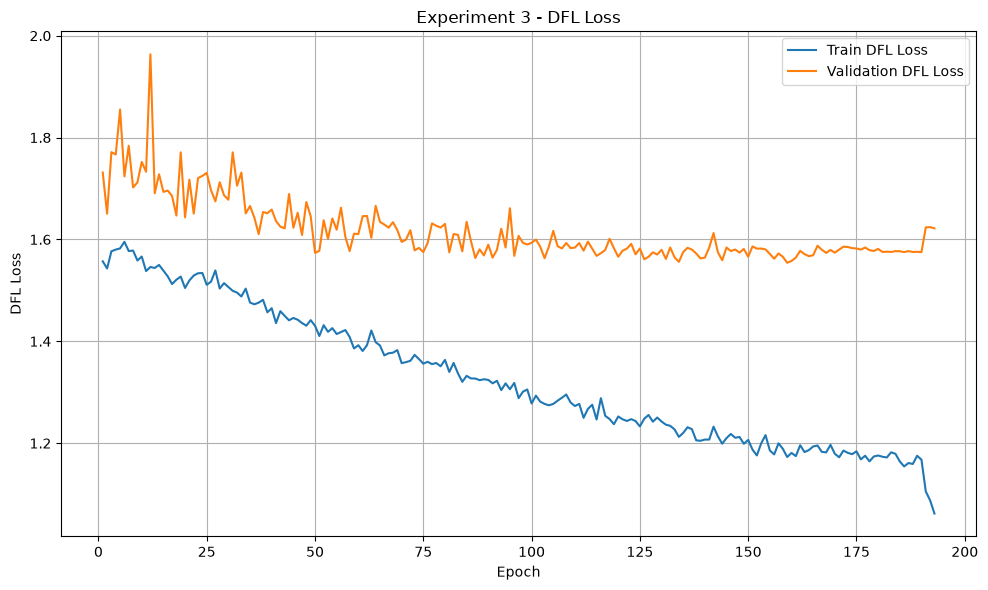

In [16]:
plt.figure(figsize=(10, 6))

plt.plot(
    df["epoch"],
    df["train/dfl_loss"],
    label="Train DFL Loss"
)

plt.plot(
    df["epoch"],
    df["val/dfl_loss"],
    label="Validation DFL Loss"
)

plt.xlabel("Epoch")
plt.ylabel("DFL Loss")
plt.title("Experiment 3 - DFL Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    RUN_DIR / "exp3_dfl_loss.png",
    dpi=200
)

plt.show()

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    df["epoch"],
    df["metrics/mAP50(B)"],
    label="mAP50"
)

plt.plot(
    df["epoch"],
    df["metrics/mAP50-95(B)"],
    label="mAP50-95"
)

plt.xlabel("Epoch")
plt.ylabel("mAP")
plt.title("Experiment 3 - Validation mAP")
plt.legend()
plt.grid(True)

plt.tight_layout()


plt.savefig(
    RUN_DIR / "exp3_map_curves.png",
    dpi=200
)

plt.show()

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    df["epoch"],
    df["metrics/precision(B)"],
    label="Precision"
)

plt.plot(
    df["epoch"],
    df["metrics/recall(B)"],
    label="Recall"
)

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Experiment 3 - Precision and Recall")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    RUN_DIR / "exp3_precision_recall.png",
    dpi=200
)

plt.show()

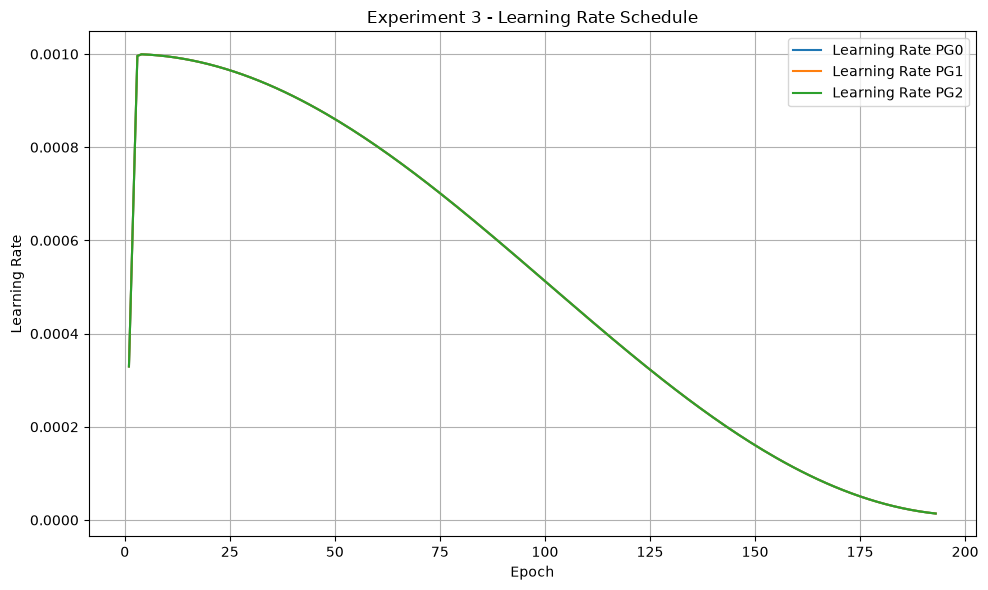

In [18]:
plt.figure(figsize=(10, 6))

plt.plot(
    df["epoch"],
    df["lr/pg0"],
    label="Learning Rate PG0"
)

plt.plot(
    df["epoch"],
    df["lr/pg1"],
    label="Learning Rate PG1"
)

plt.plot(
    df["epoch"],
    df["lr/pg2"],
    label="Learning Rate PG2"
)

plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Experiment 3 - Learning Rate Schedule")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    RUN_DIR / "exp3_learning_rate.png",
    dpi=200
)

plt.show()

In [19]:
best_model = YOLO(str(BEST_MODEL))

print("Best model loaded:")
print(BEST_MODEL)

Best model loaded:
/workspace/runs/cardd/experiment_3_reduced_training_strategy/weights/best.pt


In [20]:
validation_results = best_model.val(
    data=DATA_YAML,
    split="val",
    imgsz=IMAGE_SIZE,
    batch=BATCH_SIZE,
    device=DEVICE,
    workers=WORKERS
)

print("Experiment 3 validation completed.")

Ultralytics 8.4.144 🚀 Python-3.12.3 torch-2.8.0+cu128 CUDA:0 (NVIDIA A40, 45488MiB)
YOLO11n summary (fused): 100 layers, 2,583,322 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 1.0±0.1 ms, read: 161.4±53.4 MB/s, size: 764.5 KB)
val: Scanning /workspace/CarDD_YOLO_Reduced/CarDD_YOLO_Reduced/labels/val.cache... 810 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 810/810 60.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 51/51 9.3it/s 5.5s0.1ss
                   all        810       1744       0.74      0.608      0.654        0.5
                  dent        352        501      0.662      0.443      0.487      0.246
               scratch        431        728      0.615       0.43      0.441      0.238
                 crack        122        177      0.468       0.26      0.274      0.129
         glass shatter        134        135      0.956      0.961      0.987      0.881
           

In [21]:
precision = validation_results.box.mp
recall = validation_results.box.mr
map50 = validation_results.box.map50
map50_95 = validation_results.box.map

print("Experiment 3 - Best Model Validation")
print("=" * 50)

print(f"Precision:  {precision:.4f}")
print(f"Recall:     {recall:.4f}")
print(f"mAP50:      {map50:.4f}")
print(f"mAP50-95:   {map50_95:.4f}")

Experiment 3 - Best Model Validation
Precision:  0.7404
Recall:     0.6081
mAP50:      0.6538
mAP50-95:   0.5005


In [22]:
class_names = data["names"]

print("Per-Class Validation Results")
print("=" * 70)

for i, class_name in class_names.items():
    print(
        f"{class_name:15} | "
        f"Precision: {validation_results.box.p[i]:.4f} | "
        f"Recall: {validation_results.box.r[i]:.4f} | "
        f"mAP50: {validation_results.box.ap50[i]:.4f} | "
        f"mAP50-95: {validation_results.box.ap[i]:.4f}"
    )

Per-Class Validation Results
dent            | Precision: 0.6623 | Recall: 0.4431 | mAP50: 0.4875 | mAP50-95: 0.2465
scratch         | Precision: 0.6152 | Recall: 0.4299 | mAP50: 0.4406 | mAP50-95: 0.2375
crack           | Precision: 0.4677 | Recall: 0.2599 | mAP50: 0.2739 | mAP50-95: 0.1286
glass shatter   | Precision: 0.9558 | Recall: 0.9608 | mAP50: 0.9870 | mAP50-95: 0.8806
lamp broken     | Precision: 0.8254 | Recall: 0.7163 | mAP50: 0.8112 | mAP50-95: 0.6583
tire flat       | Precision: 0.9158 | Recall: 0.8387 | mAP50: 0.9230 | mAP50-95: 0.8513


In [23]:
final_metrics = pd.DataFrame({
    "experiment": ["Experiment 3"],
    "model": ["YOLO11n"],
    "split": ["validation"],
    "precision": [precision],
    "recall": [recall],
    "mAP50": [map50],
    "mAP50-95": [map50_95]
})

FINAL_METRICS_PATH = RUN_DIR / "experiment_3_final_validation_metrics.csv"

final_metrics.to_csv(
    FINAL_METRICS_PATH,
    index=False
)

final_metrics

,experiment,model,split,precision,recall,mAP50,mAP50-95
0,Experiment 3,YOLO11n,validation,0.740389,0.60813,0.653843,0.500476


In [24]:
comparison = pd.DataFrame({
    "Experiment": [
        "Exp1 - Baseline",
        "Exp2 - Augmentation",
        "Exp3 - Training Strategy"
    ],

    "Precision": [
        0.632,
        0.675,
        precision
    ],

    "Recall": [
        0.498,
        0.646,
        recall
    ],

    "mAP50": [
        0.499,
        0.655,
        map50
    ],

    "mAP50-95": [
        0.388,
        0.491,
        map50_95
    ]
})

comparison

,Experiment,Precision,Recall,mAP50,mAP50-95
0,Exp1 - Baseline,0.632000,0.49800,0.499000,0.388000
1,Exp2 - Augmentation,0.675000,0.64600,0.655000,0.491000
2,Exp3 - Training Strategy,0.740389,0.60813,0.653843,0.500476


In [25]:
exp2_map50_95 = 0.491
exp2_map50 = 0.655
exp2_precision = 0.675
exp2_recall = 0.646

improvement = pd.DataFrame({
    "Metric": [
        "Precision",
        "Recall",
        "mAP50",
        "mAP50-95"
    ],

    "Exp2": [
        exp2_precision,
        exp2_recall,
        exp2_map50,
        exp2_map50_95
    ],

    "Exp3": [
        precision,
        recall,
        map50,
        map50_95
    ]
})

improvement["Difference"] = (
    improvement["Exp3"] - improvement["Exp2"]
)

improvement

,Metric,Exp2,Exp3,Difference
0,Precision,0.675,0.740389,0.065389
1,Recall,0.646,0.608130,-0.037870
2,mAP50,0.655,0.653843,-0.001157
3,mAP50-95,0.491,0.500476,0.009476


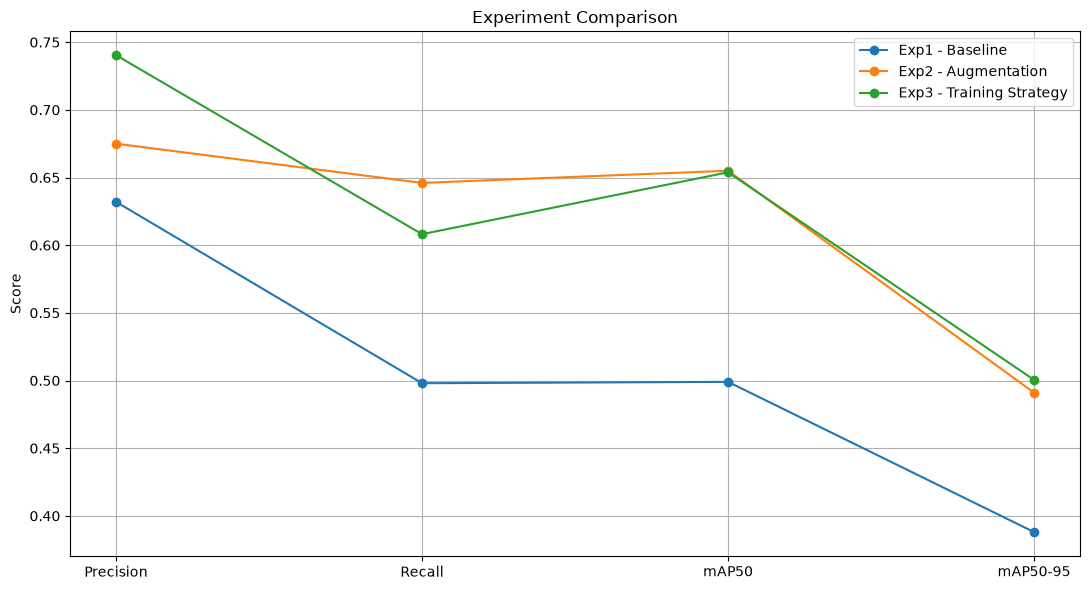

In [26]:
metrics = ["Precision", "Recall", "mAP50", "mAP50-95"]

plt.figure(figsize=(11, 6))

x = range(len(metrics))

plt.plot(
    x,
    comparison.loc[0, metrics],
    marker="o",
    label="Exp1 - Baseline"
)

plt.plot(
    x,
    comparison.loc[1, metrics],
    marker="o",
    label="Exp2 - Augmentation"
)

plt.plot(
    x,
    comparison.loc[2, metrics],
    marker="o",
    label="Exp3 - Training Strategy"
)

plt.xticks(x, metrics)

plt.ylabel("Score")
plt.title("Experiment Comparison")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    RUN_DIR / "experiment_comparison.png",
    dpi=200
)

plt.show()